# Research Paper RAG Assistant with LangChain & LangGraph

### Documents: Fundamental Deep Learning Research Papers

This project leverages three seminal research papers from ArXiv:
1. **Attention Is All You Need** (Transformer Architecture)
2. **Deep Residual Learning for Image Recognition** (ResNet)
3. **Language Models are Few-Shot Learners** (GPT-3)

---

## Problem Statement

Deep learning research moves fast. Keeping up with the latest architectures and techniques requires reading and understanding dense technical PDFs.

What if we could **chat with these papers**?

We aim to build a **smart, RAG-based chatbot** that allows users to ask natural questions and receive context-aware, AI-generated answers directly from these research papers.

This bot will combine:
- Recursive chunking (to structure the text),
- Vector embeddings (to understand meaning),
- ChromaDB (to store and search content),
- Retrieval (to find relevant sections),
- GPT (to generate natural, conversational responses).

Whether the user asks:
- "How does the multi-head attention mechanism work?"
- "What is the vanishing gradient problem in deep networks?"
- or "How does GPT-3 handle few-shot learning?"

…the chatbot will instantly find the most relevant parts of the documents and provide clear, helpful answers.

> In short: We're building an **AI assistant** that transforms dense research PDFs into a **conversational experience**.


In [1]:
# Install necessary libraries
# !pip install -qU langchain==0.3.0 langchain-openai==0.2.0 langchain-community==0.3.0 chromadb==0.5.5 tiktoken==0.7.0 arxiv==2.1.3 pymupdf==1.24.10 langgraph==0.2.20
# Uncomment as needed:
# !pip install -qU langchain-google-genai==2.0.0
# !pip install -qU langchain-anthropic==0.2.0
!pip install -qU langchain==1.2.7 langchain-openai==1.1.7 langchain-google-genai==4.2.0 langchain-community==0.4.1 chromadb==1.4.1 tiktoken arxiv==2.1.3 pymupdf==1.24.10 langgraph==1.0.7 langgraph-sdk>=0.1.57 langchain-text-splitters==1.1.0 langchain-chroma==1.1.0 rank_bm25==0.2.2

In [2]:
import os
import getpass
from langchain_chroma import Chroma
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import ArxivLoader
from langchain_classic.schema import Document
from langchain_classic.chains import RetrievalQA
import warnings
warnings.filterwarnings("ignore")


In [3]:
# Configuration
LLM_PROVIDER = "openai"  # Options: "openai", "google", "anthropic"

# Set API Key (User should replace this or set it via input)
if "OPENAI_API_KEY" not in os.environ:
    os.environ["OPENAI_API_KEY"] = getpass.getpass("Enter OpenAI API Key: ")

# Example for others (commented out):
# os.environ["GOOGLE_API_KEY"] = "..."
# os.environ["ANTHROPIC_API_KEY"] = "..."


Enter OpenAI API Key: ··········


In [4]:
def get_llm_model(provider=LLM_PROVIDER):
    if provider == "openai":
        return ChatOpenAI(model="gpt-4o", temperature=0)
    elif provider == "google":
        # from langchain_google_genai import ChatGoogleGenerativeAI
        # return ChatGoogleGenerativeAI(model="gemini-pro")
        raise NotImplementedError("Uncomment google imports to use Gemini")
    elif provider == "anthropic":
        # from langchain_anthropic import ChatAnthropic
        # return ChatAnthropic(model="claude-3-opus-20240229")
        raise NotImplementedError("Uncomment anthropic imports to use Claude")
    else:
        raise ValueError(f"Unknown provider: {provider}")

def get_embedding_model(provider=LLM_PROVIDER):
    if provider == "openai":
        return OpenAIEmbeddings(model="text-embedding-3-small")
    elif provider == "google":
        # from langchain_google_genai import GoogleGenerativeAIEmbeddings
        # return GoogleGenerativeAIEmbeddings(model="models/embedding-001")
        raise NotImplementedError("Uncomment google imports to use Gemini embeddings")
    else:
        # Fallback to OpenAI or specific implementation
        return OpenAIEmbeddings(model="text-embedding-3-small")


In [5]:
# Define a Function to Load Papers from Arxiv
def load_arxiv_papers(paper_ids):
    all_docs = []
    for paper_id in paper_ids:
        print(f"Loading paper {paper_id}...")
        loader = ArxivLoader(query=paper_id, load_max_docs=1)
        docs = loader.load()
        # Add metadata to identify the paper
        for doc in docs:
            doc.metadata['source_paper_id'] = paper_id
        all_docs.extend(docs)
        print(f"Loaded {len(docs)} document(s) for paper {paper_id}.")

    print(f"Successfully loaded total {len(all_docs)} documents.")
    return all_docs

In [6]:
# Arxiv IDs for: Attention Is All You Need, ResNet, GPT-3
paper_ids = ["1706.03762", "1512.03385", "2005.14165"]

# Load the documents
docs = load_arxiv_papers(paper_ids)


Loading paper 1706.03762...
Loaded 1 document(s) for paper 1706.03762.
Loading paper 1512.03385...
Loaded 1 document(s) for paper 1512.03385.
Loading paper 2005.14165...
Loaded 1 document(s) for paper 2005.14165.
Successfully loaded total 3 documents.


In [7]:
def chunk_documents(documents, chunk_size=500, chunk_overlap=50):
    """
    Chunks documents using RecursiveCharacterTextSplitter.
    """
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=chunk_size,
        chunk_overlap=chunk_overlap
    )
    return splitter.split_documents(documents)

# Chunk the document
chunked_docs = chunk_documents(docs)
print(f" Total Chunks Created: {len(chunked_docs)}")


 Total Chunks Created: 745


In [8]:
# Initialize the embedding model using our utility function
embeddings = get_embedding_model()

In [9]:
def store_embeddings(docs, persist_directory="chroma_research_papers"):
    """
    Creates embeddings and stores them in a local ChromaDB vector store.
    """

    vector_store = Chroma.from_documents(docs, embedding=embeddings, persist_directory=persist_directory)
    # vector_store.persist() # Not needed in newer Chroma versions, but kept for compatibility if needed
    return vector_store

# Create and store embeddings
vectorstore = store_embeddings(chunked_docs)


In [12]:
def retrieve_chunks(query, vectorstore, top_k=5):
    """
    Retrieves top_k relevant chunks from ChromaDB using semantic search.
    """
    return vectorstore.similarity_search(query, k=top_k)

# Example query
query = "What is the main contribution of the Transformer paper?"
retrieved_docs = retrieve_chunks(query, vectorstore)
print(len(retrieved_docs))

5


In [13]:
def generate_answer(query, top_chunks):
    """
    Generates a response based on top retrieved chunks using the configured LLM.
    """
    llm = get_llm_model()

    context = "\\n\\n".join([doc.page_content for doc in top_chunks])

    # Create a simple prompt
    from langchain_core.messages import HumanMessage, SystemMessage

    messages = [
        SystemMessage(content="You are a helpful AI assistant specialized in research papers. Use the provided context to answer the user's question."),
        HumanMessage(content=f"Context:\n{context}\n\nQuestion: {query}\nAnswer:")
    ]

    response = llm.invoke(messages)
    return response.content


In [14]:
def research_paper_rag_pipeline(user_query):
    """
    Full pipeline: Load (pre-loaded) -> Chunk (pre-chunked) -> Embed (stored) -> Retrieve -> Generate
    Note: In this notebook flow, we assume 'vectorstore' is already created globally.
    """
    retrieved = retrieve_chunks(user_query, vectorstore)
    answer = generate_answer(user_query, retrieved)
    return answer

# Example usage
response = research_paper_rag_pipeline("How does the Transformer architecture handle long-range dependencies?")
print(response)

The Transformer architecture handles long-range dependencies by relying entirely on self-attention mechanisms. Unlike recurrent neural networks (RNNs) or convolutional neural networks (CNNs), which can struggle with modeling dependencies over long distances due to their sequential nature, the self-attention mechanism in the Transformer allows it to model dependencies without regard to the distance between input or output positions. This is achieved by computing attention scores for all positions in the input sequence simultaneously, enabling the model to directly relate any two positions regardless of their distance. This parallel processing capability not only improves the efficiency of the model but also enhances its ability to capture long-range dependencies effectively.


### Inference: Generative Response from LLMs

#### How `research_paper_rag_pipeline` Generates Output

1. **Load Papers**  
   We use `ArxivLoader` to fetch specific research papers (Transformer, ResNet, GPT-3) directly from ArXiv.

2. **Chunk Documents**  
   The text is split into manageable chunks using `RecursiveCharacterTextSplitter`.

3. **Embed & Store**  
   Chunks are converted into embeddings using the configured provider (e.g., OpenAI `text-embedding-3-small`) and stored in ChromaDB.

4. **Retrieve**  
   Semantic search finds the most relevant chunks for the user's query.

5. **Generate**  
   The context and query are passed to the LLM (e.g., GPT-4o) to generate a grounded response.


#### Hands-On Activity: Exploring and Evaluating the RAG Pipeline

1. **Customize Chunking Strategy**  
   Modify the `chunk_documents()` function to experiment with different chunk sizes and overlap values.  
   - Try configurations such as `chunk_size=300`, `chunk_overlap=50` and compare with `chunk_size=500`, `chunk_overlap=100`.  
   - Observe how these changes impact the retrieval accuracy and the final generated answer.

2. **Implement Hybrid Search for Retrieval**  
   Enhance the `retrieve_chunks()` function by integrating a hybrid search method that combines both keyword-based (e.g., BM25) and embedding-based semantic search.  
   - Assess whether hybrid retrieval improves the relevance of the retrieved chunks.

3. **Apply LLM-Based Reranking**  
   Introduce a reranking step after initial chunk retrieval.  
   - Use the LLM to rank the chunks based on relevance and return only the top 3 before generating the final answer.  
   - Compare the answer quality with the default top-5 retrieval method.



#### Evaluation Task: Determine the Most Effective Strategy

Using the same query (e.g., "How does the attention mechanism differ from RNNs?"), apply all three methods above and compare the results.

Evaluate each answer based on the following criteria:
- Relevance to the original query
- Completeness and coverage of information
- Clarity and fluency of the response

After reviewing the outputs, identify which technique provided the best overall answer and justify your reasoning based on observed differences.


### Bonus: Building the RAG Pipeline with LangGraph

In this section, we will reimplement the RAG workflow using **LangGraph**. LangGraph allows us to define the flow as a state machine, making it easier to add complex logic like loops, conditional branching, and state persistence.

We will define a simple linear graph: **Start -> Retrieve -> Generate -> End**.

In [15]:
from langgraph.graph import StateGraph, START, END
from typing_extensions import TypedDict
from typing import List

# 1. Define the State
class AgentState(TypedDict):
    question: str
    context: List[Document]
    answer: str


In [17]:
# 2. Define the Nodes

def retrieve_node(state: AgentState):
    """
    Retrieves relevant documents from the vector store.
    """
    print(f"Retrieving context for: {state['question']}")
    # We use the global 'vectorstore' created earlier
    retrieved_docs = vectorstore.similarity_search(state['question'], k=5)
    return {"context": retrieved_docs}

def generate_node(state: AgentState):
    """
    Generates an answer using the LLM and the retrieved context.
    """
    print("Generating answer...")
    question = state['question']
    docs = state['context']

    # Re-use our existing generation logic or call the LLM directly
    # Here we construct the prompt manually for clarity within the node
    context_str = "\\n\\n".join([d.page_content for d in docs])

    llm = get_llm_model()
    from langchain_core.messages import HumanMessage, SystemMessage

    messages = [
        SystemMessage(content="You are a helpful AI assistant specialized in research papers."),
        HumanMessage(content=f"Context:\n{context_str}\n\nQuestion: {question}\nAnswer:")
    ]

    response = llm.invoke(messages)
    return {"answer": response.content}


In [18]:
# 3. Build the Graph
workflow = StateGraph(AgentState)

# Add nodes
workflow.add_node("retrieve", retrieve_node)
workflow.add_node("generate", generate_node)

# Add edges
workflow.add_edge(START, "retrieve")
workflow.add_edge("retrieve", "generate")
workflow.add_edge("generate", END)

# Compile the graph
app = workflow.compile()

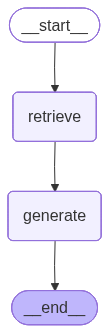

In [19]:
# 4. Visualize the Graph (Optional)
from IPython.display import Image, display
try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception as e:
    print("Could not visualize graph (requires graphviz/mermaid):", e)

In [20]:
# 5. Run the Graph
initial_state = {"question": "How does the residual connection help in training deep networks?"}
result = app.invoke(initial_state)

print("\n--- Final Answer ---\n")
print(result["answer"])

Retrieving context for: How does the residual connection help in training deep networks?
Generating answer...

--- Final Answer ---

The residual connection helps in training deep networks by addressing the degradation problem, which is the difficulty in training deeper networks due to vanishing gradients and optimization challenges. In a residual network, instead of each set of layers trying to learn a direct mapping \( H(x) \), they learn a residual mapping \( F(x) = H(x) - x \). This reformulation allows the network to learn the difference between the input and the desired output, which is often easier to optimize.

The residual connection, typically implemented as a shortcut or skip connection, directly adds the input \( x \) to the output of the stacked layers \( F(x) \). This addition helps in several ways:

1. **Gradient Flow**: The shortcut connection provides a direct path for gradients to flow backward through the network, mitigating the vanishing gradient problem and allowin